# Nashville City Cemetery — Cause of Death Analysis

An exploration of burials in Nashville's city cemeteries from 1846–1979: causes of death, mortality trends, and demographics over time.

## Part 1: Cleaning "Cause of Death"

The raw cause-of-death text is full of 19th-century spelling variation. The goal is a clean **"Cause of Death Updated"** column: same-cause variants merged (all cancers → "Cancer"), genuinely different diagnoses kept apart (Scarlet Fever ≠ Yellow Fever).

Load the burial records and take a first look.

In [1]:
import re
import pandas as pd

Nashville_City_Cemetary= "Historic_Nashville_City_Cemetery_Interments__1846-1979.xlsx"

df = pd.read_excel(Nashville_City_Cemetary)
print(df.shape)
df.head()

(19745, 14)


,Volume,Name,Burial Month,Month No.,Burial Day,Burial Year,Sex,Race,Age,Residence,Cause of Death/Burial,Ave,Section/Lot,Remarks
0,6B,"Bell, Nancy Ann",Aug,8.0,6.0,1979.0,F,W,10.0,NaN,NaN,Oak,"sec. 28 NW, lot 12",J. L. Hughes lot
1,6W,"Drake, Mary Edith Smith, Mrs.",May,5.0,19.0,1979.0,F,W,67.0,"Madison, Tenn",Cancer,"Locust, Boyd Lot",lot 10,"wife of Alex M. Drake, Madison Funeral Home Of..."
2,6D,"Davis, Bessie",Sep,9.0,19.0,1979.0,F,W,90.0,Nashville,Old Age,Poplar,"McAllister, E25, lot 8",daughter of Helen Davis
3,6C,"Creech, Emily Green",Aug,8.0,NaN,1978.0,F,W,91.0,Nashville,NaN,sect.ion 9,15,Magnolia
4,6W,"Creech, Emily Green",Aug,8.0,NaN,1978.0,F,W,91.0,"Nashville, Tennessee",NaN,NaN,NaN,Malgnolia


19,745 burial records, 14 columns, spanning 1846–1979. The column called `Cause of Death/Burial` will be the focus of this project. 

Use .describe to see how messy the raw date values are. We can compare to the total rows to determine how many are missing values. 

In [2]:
COD = "Cause of Death/Burial"

print("Total rows:", len(df))
print(df[COD].describe())
print("Blank/missing:", len(df) - df[COD].count())

vc = df[COD].value_counts()
print("\nTop 40 raw values:")
vc.head(40)

Total rows: 19745
count           19428
unique           2208
top       Consumption
freq             1767
Name: Cause of Death/Burial, dtype: object
Blank/missing: 317

Top 40 raw values:


Cause of Death/Burial
Consumption       1767
Unknown           1260
Still Born         841
Cholrea            667
Not Known          639
Old Age            604
Cholera            575
Pneumonia          516
Flux               469
Complication       446
Cold               421
Teething           411
Typhoid Fever      310
Complicated        302
Brain Fever        286
Dropsy             284
Stil Born          278
Measles            236
Measels            224
Whooping Cough     205
Small Pox          196
Scarlot Fever      192
Infl of Bowels     156
Dropsey            151
Teethin            141
Feever             140
Infl of Brain      137
Fever              135
Diptheria          129
Child Bed          124
Heart Disease      114
Croup              107
Spasms             106
Lock Jaw            95
Hives               94
Cancer              94
Paralysis           93
Hooping Cough       93
Inf of Bowls        88
Croop               87
Name: count, dtype: int64

2,208 different spellings across ~19,400 records. The same cause repeats under many spellings — Cholera alone shows up as "Cholrea" (667), "Cholera" (575), and "Cholera Morbus" (17). A cleanup dictionary is needed.

## Cleaning approach

- **Merge** obvious spelling or severity variants of the same cause ("Diarrhea," "Diarrhaea," "Chronic Diarrhea" → "Diarrhea").
- **Keep separate** diagnoses that just sound alike (`Cholera` vs. `Cholera Infantum`; `Scarlet Fever` vs. `Yellow Fever`).
- Built as an auditable, **exact-match dictionary** covering the ~250 most common raw values (~86% of records). Rarer entries are left lightly cleaned (trimmed, title-cased) rather than force-fit into a bucket.

Steps for creating the dictionary: 
 - First, define a function called norm_keys with parameter s being any given value in the cause of death/burial column. 
 - If the value is null, return "None" 
 - Otherwise, use a regex forumula to normalize the values (turn all values into strings, then make them lower case and remove white spaces).


In [3]:
def norm_key(s):
    """Lowercase + collapse whitespace, for dictionary lookups only (display uses the mapped value)."""
    if pd.isna(s):
        return None
    return re.sub(r"\s+", " ", str(s).strip().lower())


# Exact-match spelling-fix + grouping dictionary.
# Keys are normalized (lowercase/stripped) raw values actually observed in the data.
COD_MAP = {
    # --- Unknown / not recorded ---
    "unknown": "Unknown", "not known": "Unknown", "not know": "Unknown",

    # --- Stillbirth vs. premature birth (kept separate: premature != born dead) ---
    "still born": "Stillborn", "stil born": "Stillborn", "stillborn": "Stillborn",
    "still bornd": "Stillborn", "stilborn": "Stillborn", "still borned": "Stillborn",
    "premature birth": "Premature Birth", "premature": "Premature Birth",

    "old age": "Old Age",

    # --- Cholera vs. Cholera Infantum (distinct infant diarrheal illness, not the bacterial disease) ---
    "cholrea": "Cholera", "cholera": "Cholera", "cholera morbus": "Cholera",
    "cholrea morbus": "Cholera", "cholra morbus": "Cholera", "said cholera": "Cholera",
    "cholera infantum": "Cholera Infantum", "cholera inphantum": "Cholera Infantum",
    "cholrea infantum": "Cholera Infantum", "colney inphantom": "Cholera Infantum",

    # --- Pneumonia ("Lung Fever" was a period synonym) ---
    "pneumonia": "Pneumonia", "pneumonie": "Pneumonia", "pneuminia": "Pneumonia",
    "numonia": "Pneumonia", "pnemonia": "Pneumonia", "pnenmonia": "Pneumonia",
    "penumonia": "Pneumonia", "bronchial pneumonia": "Pneumonia", "broncial pneumonia": "Pneumonia",
    "lung fever": "Pneumonia",
    "typhoid pneumonia": "Typhoid Pneumonia",  # kept separate: comorbid diagnosis, not plain pneumonia

    # --- Dysentery ("Flux"/"bloody flux" was the period lay-term for dysentery) --- JUDGMENT CALL
    "flux": "Dysentery", "flucks": "Dysentery",
    "dysentery": "Dysentery", "dysentary": "Dysentery", "disentery": "Dysentery", "dyentery": "Dysentery",

    # --- Diarrhea (chronic variants folded in, same underlying cause) ---
    "diarrhaea": "Diarrhea", "diarherea": "Diarrhea", "diarrhea": "Diarrhea", "diarhea": "Diarrhea",
    "diareah": "Diarrhea", "diarhoera": "Diarrhea", "diarrhoea": "Diarrhea", "ch diarrhaea": "Diarrhea",
    "chronic diareah": "Diarrhea", "ch diarrhoea": "Diarrhea", "chronic diarrhea": "Diarrhea",
    "chronic diar": "Diarrhea", "diarhaea": "Diarrhea", "diarhoerea": "Diarrhea", "diarhoea": "Diarrhea",

    "teething": "Teething", "teethin": "Teething", "teathing": "Teething",

    "typhoid fever": "Typhoid Fever", "typh. fever": "Typhoid Fever", "typh fever": "Typhoid Fever",
    "tyfoid fever": "Typhoid Fever", "typhoyd fever": "Typhoid Fever",
    "t. feever": "Typhoid Fever",  # JUDGMENT CALL: assumed abbreviation for Typhoid Fever

    # --- Brain Fever / Congestion of Brain / Inflammation of Brain kept as three separate
    #     period diagnoses (same caution as Scarlet vs. Yellow Fever) --- JUDGMENT CALL
    "brain fever": "Brain Fever", "brain feever": "Brain Fever", "brane fever": "Brain Fever",
    "infl of brain": "Inflammation of Brain", "infl of brain ": "Inflammation of Brain",
    "inf of brain": "Inflammation of Brain", "infl brain": "Inflammation of Brain",
    "inft of brain": "Inflammation of Brain", "inf of brains": "Inflammation of Brain",
    "infl of the brain": "Inflammation of Brain", "infl of brian": "Inflammation of Brain",
    "infl of the brain ": "Inflammation of Brain", "inflamation brain": "Inflammation of Brain",
    "inflamation of brain": "Inflammation of Brain", "inf brain": "Inflammation of Brain",
    "congestion of brain": "Congestion of Brain", "cong of brain": "Congestion of Brain",
    "congestion of the brain": "Congestion of Brain", "congestion brain": "Congestion of Brain",
    "conjestion of brain": "Congestion of Brain",

    "small pox": "Smallpox",

    # --- Scarlet Fever vs. Yellow Fever kept separate (distinct diseases); "Yellow Janders"
    #     is "Yellow Jaundice" (not Yellow Fever) so it's grouped with Jaundice instead ---
    "scarlot fever": "Scarlet Fever", "scarlet fever": "Scarlet Fever",
    "scarlett fever": "Scarlet Fever", "scarlett feever": "Scarlet Fever",
    "s. feever": "Scarlet Fever",  # JUDGMENT CALL: assumed abbreviation for Scarlet Fever
    "yellow fever": "Yellow Fever",
    "jaundice": "Jaundice", "jondice": "Jaundice", "yellow janders": "Jaundice",

    "whooping cough": "Whooping Cough", "hooping cough": "Whooping Cough",
    "hooping cough ": "Whooping Cough", "whooping cough ": "Whooping Cough", "whoping cough": "Whooping Cough",

    "diptheria": "Diphtheria", "diphtherie": "Diphtheria", "dyptheria": "Diphtheria",
    "diphtheria": "Diphtheria", "diphthera": "Diphtheria",

    # --- Measles ---
    "measles": "Measles", "measels": "Measles", "measeles": "Measles",

    # --- Childbirth-related deaths grouped together, incl. "Child Bed Fever" (puerperal fever) --- JUDGMENT CALL
    "child bed": "Childbirth", "child bed fever": "Childbirth", "child birth": "Childbirth",
    "died in child bed": "Childbirth", "child bed ": "Childbirth", "child bead": "Childbirth",

    # --- Heart Disease ---
    "heart disease": "Heart Disease", "disease of heart": "Heart Disease", "dis of hart": "Heart Disease",
    "hart dis": "Heart Disease", "heart diseas": "Heart Disease", "heart disease ": "Heart Disease",
    "dis. of the heart": "Heart Disease", "dis of the heart": "Heart Disease",
    "affection of the heart": "Heart Disease", "aff of the heart": "Heart Disease",
    "aff. of the heart": "Heart Disease", "of the heart": "Heart Disease", "affection of heart": "Heart Disease",
    "heart trouble": "Heart Disease", "heart failure": "Heart Disease",
    "palpitation of the heart": "Heart Disease", "hart disease": "Heart Disease",
    "enlargement of hart": "Heart Disease", "dropsy of heart": "Heart Disease", "dropsey of heart": "Heart Disease",
    "heart": "Heart Disease", "disease of hart": "Heart Disease", "affection of the hart": "Heart Disease",

    # --- Cancer ---
    "cancer": "Cancer", "cancer of stomach": "Cancer", "canser": "Cancer", "cancer of hart": "Cancer",

    "paralysis": "Paralysis", "paralisis": "Paralysis", "peralysis": "Paralysis",

    "lock jaw": "Lockjaw (Tetanus)", "lockjaw": "Lockjaw (Tetanus)", "lock jaw ": "Lockjaw (Tetanus)",

    "hives": "Hives", "bold hives": "Hives",

    "worms": "Worms", "wormes": "Worms",

    "drowned": "Drowned", "drownded": "Drowned", "drownd": "Drowned", "drowning": "Drowned",

    # --- "Summer Complaint" kept separate from Cholera Infantum: distinct contemporary label
    #     even though both are infant summer diarrheal illness --- JUDGMENT CALL
    "summer complt": "Summer Complaint", "summer complaint": "Summer Complaint",
    "sumer complaint": "Summer Complaint", "sum complaint": "Summer Complaint",
    "sumer complain": "Summer Complaint", "summer complant": "Summer Complaint",
    "summer comp": "Summer Complaint", "sumer complant": "Summer Complaint", "sumer comp": "Summer Complaint",

    "apoplexy": "Apoplexy (Stroke)", "appoplexy": "Apoplexy (Stroke)", "aperplexy": "Apoplexy (Stroke)",

    "rheumatism": "Rheumatism", "rhumatism": "Rheumatism", "inflamatory rhumatism": "Rheumatism",

    # --- Scrofula kept separate from Consumption even though both are forms of TB:
    #     clerks used a distinct label for it --- JUDGMENT CALL
    "scrofula": "Scrofula", "scroffula": "Scrofula", "scrofalow": "Scrofula", "scroffalo": "Scrofula",

    # --- Convulsions / Spasms / Fits kept as three separate categories (same caution as fevers) --- JUDGMENT CALL
    "convulsions": "Convulsions", "convulsion": "Convulsions",
    "spasms": "Spasms", "spasom": "Spasms", "spasoms": "Spasms", "spasams": "Spasms", "spasm": "Spasms",
    "fits": "Fits", "fitts": "Fits", "fit": "Fits",

    "croup": "Croup", "croop": "Croup", "croope": "Croup", "croupe": "Croup", "crupe": "Croup",
    "mem croup": "Croup",  # JUDGMENT CALL: membranous croup folded into Croup

    # --- Dropsy: "in head" (hydrocephalus) and "in chest" (pleural effusion) kept distinct ---
    "dropsy": "Dropsy", "dropsey": "Dropsy",
    "dropsey in head": "Dropsy in Head", "dropsey in chest": "Dropsy in Chest",

    "infl of bowels": "Inflammation of Bowels", "infl of the bowels": "Inflammation of Bowels",
    "infl bowels": "Inflammation of Bowels", "inf of bowls": "Inflammation of Bowels",
    "infl of bowels ": "Inflammation of Bowels", "inft of bowels": "Inflammation of Bowels",
    "infl bowls": "Inflammation of Bowels", "inf of bowels": "Inflammation of Bowels",
    "inf bowls": "Inflammation of Bowels", "inf bowels": "Inflammation of Bowels",
    "inflamation of bowels": "Inflammation of Bowels", "inflamation bowels": "Inflammation of Bowels",

    # --- Congestive Chill (period term, likely malaria/ague-related) grouped together ---
    "congestive chill": "Congestive Chill", "congestive chills": "Congestive Chill",
    "cong chill": "Congestive Chill", "conjestive chill": "Congestive Chill",
    "conjestive chills": "Congestive Chill", "conjestive feever": "Congestive Chill",

    # --- Malaria-family fevers grouped together --- JUDGMENT CALL (folding "Malarial Fever" in)
    "intermittent fever": "Intermittent Fever (Malaria)", "int fever": "Intermittent Fever (Malaria)",
    "malarial fever": "Intermittent Fever (Malaria)",
    "bilious fever": "Bilious Fever", "billious fever": "Bilious Fever",

    "meningitis": "Meningitis", "meningetis": "Meningitis",

    "bronchitis": "Bronchitis", "bronchitus": "Bronchitis", "bronchthis": "Bronchitis",

    "asthma": "Asthma",
    "mumps": "Mumps",
    "chicken pox": "Chicken Pox",

    "erysiplas": "Erysipelas", "errasipelas": "Erysipelas", "essasipelas": "Erysipelas", "erysiphlas": "Erysipelas",

    "insanity": "Insanity", "insane": "Insanity",

    "general debility": "General Debility", "gen debility": "General Debility",

    "la grippe": "Influenza",  # period French-derived term for flu

    "sore throat": "Sore Throat",
    "malignant sore throat": "Malignant Sore Throat",  # JUDGMENT CALL: kept distinct from plain sore throat

    "colitis": "Colitis", "entero colitis": "Colitis",
    "gastro enteritis": "Gastroenteritis",

    # --- Kidney Disease: Gravel (stones), Uremia, Nephritis, and Bright's Disease are all
    #     period/clinical synonyms or direct consequences of kidney disease --- JUDGMENT CALL
    "kidney disease": "Kidney Disease", "kidney trouble": "Kidney Disease", "gravel": "Kidney Disease",
    "uremia": "Kidney Disease", "nephrelis": "Kidney Disease", "chronic nephritis": "Kidney Disease",
    "brights disease": "Kidney Disease", "bright disease": "Kidney Disease",

    "dis of liver": "Liver Disease", "disease of liver": "Liver Disease", "liver complaint": "Liver Disease",
    "liver complt": "Liver Disease", "liver disease": "Liver Disease", "liver trouble": "Liver Disease",
    "liver complant": "Liver Disease",

    "womb disease": "Womb Disease", "disease of womb": "Womb Disease",

    "suicide": "Suicide", "suicide, opium": "Suicide", "suicide by taking laudanum": "Suicide",

    # --- Violent/accidental death, kept as distinguishable sub-categories rather than one bucket ---
    "gun shot": "Gunshot Wound", "gun shot wound": "Gunshot Wound", "pistol shot": "Gunshot Wound",
    "shot": "Gunshot Wound", "shot accidental": "Gunshot Wound", "pistol shott": "Gunshot Wound",
    "burnt to death": "Burns", "burned": "Burns", "burnt": "Burns", "scalded": "Burns",
    "burnd": "Burns", "burned to death": "Burns", "burnt to death ": "Burns",
    "poison": "Poisoning", "poisoned": "Poisoning", "poisan": "Poisoning", "poisand": "Poisoning",
    "blood poison": "Poisoning",
    "murdered": "Homicide", "stabed": "Homicide",
    "accident": "Accident", "railroad accident": "Accident", "acident railroad": "Accident",
    "fall": "Accident", "killed by a fall": "Accident", "died from an injury": "Accident",
    "wound": "Accident", "old wound": "Accident",
    "exposure": "Exposure", "smothered": "Suffocation", "sun stroke": "Sunstroke",
    "killed": "Killed",  # JUDGMENT CALL: too ambiguous (accident vs. homicide) to merge elsewhere
    "found dead": "Found Dead", "died suddenly": "Died Suddenly",

    "marasmus": "Marasmus",
    "quinsey": "Quinsy",

    # --- Consumption/Tuberculosis synonyms ---
    "consumption": "Consumption (Tuberculosis)", "consumson": "Consumption (Tuberculosis)",
    "tuberculosis": "Consumption (Tuberculosis)", "phthisis": "Consumption (Tuberculosis)",
    "phthisic": "Consumption (Tuberculosis)", "phthisis pulm": "Consumption (Tuberculosis)",
    "bowel consumption": "Consumption (Tuberculosis)",  # JUDGMENT CALL: intestinal TB

    # --- Complication / vague catch-alls, spelling-normalized only (not merged into anything specific
    #     since the underlying cause is unstated) ---
    "complication": "Complication", "complicated": "Complication", "complication of diseases": "Complication",
    "fever": "Fever (Unspecified)", "feever": "Fever (Unspecified)",
    "congestion": "Congestion (Unspecified)",

    "thrash": "Thrush",  # period spelling of thrush (infant oral fungal infection)

    # --- Pleurisy ---
    "pluracy": "Pleurisy", "pleurisey": "Pleurisy", "pleurisy": "Pleurisy", "pleuricy": "Pleurisy",

    # --- Lung Disease: generic/non-pneumonia lung complaints grouped together, kept
    #     separate from the clinical "Pneumonia" diagnosis --- JUDGMENT CALL
    "infl of lungs": "Lung Disease", "dis of lungs": "Lung Disease", "disease of lungs": "Lung Disease",
    "cong of lungs": "Lung Disease", "congestion of lungs": "Lung Disease", "inf of lungs": "Lung Disease",
    "affection of lungs": "Lung Disease", "aff. of lungs": "Lung Disease", "lungs": "Lung Disease",
    "lung disease": "Lung Disease", "hemorage of lungs": "Lung Disease", "infl lungs": "Lung Disease",
    "infl of the lungs": "Lung Disease",

    # --- Additional merges found via the near-duplicate check (Check 2 below): typos/abbreviations
    #     of spellings already in this dictionary, confirmed by manual review one at a time. Two
    #     near-duplicate matches were rejected as false positives and are NOT included here:
    #     "Enlargement of Liver" (correctly filed under Liver Disease below, not Heart Disease) and
    #     "Concussion of Brain" (a real, distinct head-injury diagnosis, not a Congestion of Brain typo). ---
    "dis of the hart": "Heart Disease", "heart dis": "Heart Disease", "dis of heart": "Heart Disease",
    "diseas of heart": "Heart Disease", "palpatation of heart": "Heart Disease",
    "enlargement of liver": "Liver Disease",
    "congestive fever": "Congestive Chill", "conjestive chils": "Congestive Chill",
    "burn": "Burns",
    "pluralisis": "Paralysis", "paralissis": "Paralysis",
    "congestion of brane": "Congestion of Brain", "cong brain": "Congestion of Brain",
    "infl of bowls": "Inflammation of Bowels", "of bowels": "Inflammation of Bowels",
    "inflamation of bowls": "Inflammation of Bowels", "infl. of bowels": "Inflammation of Bowels",
    "congestion of bowels": "Inflammation of Bowels",
    "aff of brain": "Inflammation of Brain", "dis of brain": "Inflammation of Brain",
    "inft brain": "Inflammation of Brain", "soft of brain": "Inflammation of Brain",
    "inf brains": "Inflammation of Brain", "aff of the brain": "Inflammation of Brain",
    "affection of the brain": "Inflammation of Brain",
    "cholney infantom": "Cholera Infantum", "cholera infnt": "Cholera Infantum",
    "cholrea inft": "Cholera Infantum", "cholra infantum": "Cholera Infantum", "cholra infantom": "Cholera Infantum",
    "smal pox": "Smallpox", "smallpox": "Smallpox",
    "scrofalaw": "Scrofula", "scofalow": "Scrofula", "scrofulo": "Scrofula",
    "diarheora": "Diarrhea", "diarah": "Diarrhea", "diarheerea": "Diarrhea", "dearherea": "Diarrhea",
    "diarheara": "Diarrhea", "diarhaerea": "Diarrhea", "diarrheara": "Diarrhea", "diarhaera": "Diarrhea",
    "chr. diarrhoea": "Diarrhea",
    "diphhuria": "Diphtheria", "dipthera": "Diphtheria", "dyptherie": "Diphtheria",
    "cansar": "Cancer", "cancer of stomache": "Cancer",
    "conjeston": "Congestion (Unspecified)",
    "hemorage lungs": "Lung Disease", "hemorge lungs": "Lung Disease", "dis of the lungs": "Lung Disease",
    "conjestion of lungs": "Lung Disease",
    "erasipelas": "Erysipelas", "eysiplas": "Erysipelas", "erisiplas": "Erysipelas", "errasiphelas": "Erysipelas",
    "conusmption": "Consumption (Tuberculosis)", "phthiric": "Consumption (Tuberculosis)",
    "phihisis": "Consumption (Tuberculosis)",
    "typh. pneumonia": "Typhoid Pneumonia", "typhoid pneuminia": "Typhoid Pneumonia", "typhoid pneu": "Typhoid Pneumonia",
    "gen dibility": "General Debility",
    "convultion": "Convulsions",
    "soar thrat": "Sore Throat",
    "murderd": "Homicide", "stabbed": "Homicide",
    "menengetis": "Meningitis", "mingitis": "Meningitis",
    "child bed feever": "Childbirth", "childbed": "Childbirth",
    "plurasy": "Pleurisy",
    "drown": "Drowned",
    "apoplxy": "Apoplexy (Stroke)",
    "dysintery": "Dysentery", "disentary": "Dysentery",
    "scarlet feever": "Scarlet Fever",
    "meales": "Measles", "miasles": "Measles",
    "summer compliant": "Summer Complaint",
    "sill born": "Stillborn",
    "cropsy": "Dropsy",
    "no known": "Unknown",
    "smoothered": "Suffocation", "smotherd": "Suffocation",
    "died from an old injury": "Accident",
    "graval": "Kidney Disease",
    "poisen": "Poisoning",
}

def clean_cause(raw):
    key = norm_key(raw)
    if key is None:
        return "Unknown"  # true blank/missing treated same as explicit "Unknown"/"Not Known" text
    if key in COD_MAP:
        return COD_MAP[key]
    return str(raw).strip().title()

df["Cause of Death Updated"] = df[COD].apply(clean_cause)
print("New unique category count:", df["Cause of Death Updated"].nunique(), "(down from", df[COD].nunique(), "raw values)")
df[[COD, "Cause of Death Updated"]].sample(15, random_state=1)

New unique category count: 1774 (down from 2208 raw values)


,Cause of Death/Burial,Cause of Death Updated
1225,Heart Disease,Heart Disease
14102,Complication,Complication
2217,Diphthera,Diphtheria
17387,Cholrea,Cholera
11639,Unknown,Unknown
9055,Measels,Measles
4664,Consumption,Consumption (Tuberculosis)
16424,Dropsey,Dropsy
10871,Scroffula,Scrofula
18483,Cholrea,Cholera


Above is a random sample of 15 rows showing the values before and after cleaning them (accounting for spelling and whitespace variations). 

The dictionary maps the most common spellings into clean categories (e.g. "Cholrea" → "Cholera," "Consumption" → "Consumption (Tuberculosis)"). Rarer one-off entries stay as their own lightly-cleaned text, which is why the unique-category count only drops modestly (2,208 → 1,774) even though the records themselves are now much cleaner — the coverage check below shows the real picture.

How much of the data did the dictionary actually resolve, and what does the cleaned data look like now?

In [4]:
# How much of the data did the dictionary actually cover, vs. fall through to raw cleanup?
mapped_mask = df[COD].apply(lambda r: norm_key(r) in COD_MAP if pd.notna(r) else True)
print(f"Rows resolved by the dictionary: {mapped_mask.sum()} ({mapped_mask.mean()*100:.1f}%)")
print(f"Rows left as lightly-cleaned original text: {(~mapped_mask).sum()} ({(~mapped_mask).mean()*100:.1f}%)")

print("\nTop 20 most frequent raw values NOT covered by the dictionary (still worth reviewing):")
uncovered = df.loc[~mapped_mask, COD].value_counts()
print(uncovered.head(20))

print("\nTop 20 categories in 'Cause of Death Updated' after cleaning:")
df["Cause of Death Updated"].value_counts().head(20)

Rows resolved by the dictionary: 17209 (87.2%)
Rows left as lightly-cleaned original text: 2536 (12.8%)

Top 20 most frequent raw values NOT covered by the dictionary (still worth reviewing):
Cause of Death/Burial
Cold                   421
Intemperance            52
Janders                 13
Inflamation             13
Cramp Cholic            11
Disease of Bowels        9
Infl of stomach          9
Chills                   7
Spinal Affection         7
Cramp                    7
Brain Trouble            6
Piles                    6
Tumor                    6
Stomach Trouble          6
Inft Stomache            6
Infl of the Stomach      6
Gastritis                6
Mortification            6
Spinal Efection          5
Stomache Trouble         5
Name: count, dtype: int64

Top 20 categories in 'Cause of Death Updated' after cleaning:


Cause of Death Updated
Unknown                       2226
Consumption (Tuberculosis)    1806
Stillborn                     1302
Cholera                       1278
Complication                   752
Pneumonia                      668
Old Age                        610
Teething                       595
Dysentery                      547
Measles                        485
Dropsy                         439
Cold                           421
Typhoid Fever                  367
Diarrhea                       335
Whooping Cough                 333
Inflammation of Bowels         321
Scarlet Fever                  309
Brain Fever                    309
Heart Disease                  291
Fever (Unspecified)            275
Name: count, dtype: int64

87.2% of records now have a clean, standardized cause of death. The unmapped 12.8% are rarer or more ambiguous terms ("Cold," "Intemperance," "Gastritis") — worth a closer look eventually, but not blocking the next step: finding the top 10 causes of death.

## Testing the cleaning step

**Check 1 — audit a category from the inside.** For a few cleaned categories, list every distinct raw spelling that fed into it. If something unexpected shows up, that's a wrong merge.

In [5]:
def audit_category(category, max_show=25):
    raw_values = sorted(df.loc[df["Cause of Death Updated"] == category, COD].dropna().unique())
    print(f"{category}: {len(raw_values)} distinct raw spellings")
    print(raw_values[:max_show])
    print()

# Includes a couple of judgment-call categories worth double-checking (Cholera vs. Cholera
# Infantum should NOT mix; Dysentery includes "Flux" on purpose).
for cat in ["Heart Disease", "Cholera", "Dysentery", "Consumption (Tuberculosis)"]:
    audit_category(cat)

Heart Disease: 39 distinct raw spellings
['Aff of the Heart', 'Aff of the heart', 'Aff. of the Heart', 'Affection of Heart', 'Affection of heart', 'Affection of the Heart', 'Affection of the heart', 'Dis of Hart', 'Dis of Heart', 'Dis of hart', 'Dis of the Hart', 'Dis of the Heart', 'Dis of the hart', 'Dis of the heart', 'Dis. of the Heart', 'Dis. of the heart', 'Diseas of Heart', 'Disease of Hart', 'Disease of Heart', 'Dropsey of Heart', 'Dropsy of Heart', 'Dropsy of heart', 'Enlargement of Hart', 'Hart Dis', 'Hart Disease']

Cholera: 8 distinct raw spellings
['Cholera', 'Cholera Morbus', 'Cholra Morbus', 'Cholra morbus', 'Cholrea', 'Cholrea Morbus', 'Said Cholera', 'cholrea']

Dysentery: 8 distinct raw spellings
['Disentary', 'Disentery', 'Dyentery', 'Dysentary', 'Dysentery', 'Dysintery', 'Flucks', 'Flux']

Consumption (Tuberculosis): 11 distinct raw spellings
['Bowel Consumption', 'Consumption', 'Consumson', 'Conusmption', 'Phihisis', 'Phthiric', 'Phthisic', 'Phthisis', 'Phthisis Pu

 All four categories check out. `Cholera` (8 spellings) contains no "infantum" variants — the two didn't get mixed up. `Dysentery` (6 spellings) includes "Flux"/"Flucks" exactly as the judgment call intended. `Consumption (Tuberculosis)` correctly bundles `Phthisis`/`Tuberculosis` synonyms. `Heart Disease` (33 spellings) is all genuinely heart-related phrasing — no stray unrelated terms leaked in. No wrong merges found in this sample.

**Check 2 — hunt for near-duplicates left uncleaned.** Scan the still-unmapped raw values (from the coverage check above) for spellings that closely resemble something already in the dictionary. A close match there is a likely missed merge, not a genuinely new cause — this is exactly how the "Measles"/"Measels" gap was caught earlier.

In [6]:
import difflib

known_keys = list(COD_MAP.keys())

print("Uncovered raw values that closely resemble an already-mapped spelling (possible missed merges):\n")
flagged = 0
for raw_val, count in uncovered.items():
    key = norm_key(raw_val)
    matches = difflib.get_close_matches(key, known_keys, n=1, cutoff=0.82)
    if matches:
        flagged += 1
        print(f"  {raw_val!r} (n={count}) -> similar to {matches[0]!r}, which maps to {COD_MAP[matches[0]]!r}")

print(f"\n{flagged} potential gaps flagged out of {len(uncovered)} uncovered raw values.")

Uncovered raw values that closely resemble an already-mapped spelling (possible missed merges):

  'Disease of Brain' (n=4) -> similar to 'dis of brain', which maps to 'Inflammation of Brain'
  'Winter Fever' (n=3) -> similar to 'int fever', which maps to 'Intermittent Fever (Malaria)'
  'Affection of Brain' (n=3) -> similar to 'affection of the brain', which maps to 'Inflammation of Brain'
  'Aff. of Brain' (n=2) -> similar to 'aff of brain', which maps to 'Inflammation of Brain'
  'Concussion of Brain' (n=2) -> similar to 'conjestion of brain', which maps to 'Congestion of Brain'
  'Dyarah' (n=2) -> similar to 'diarah', which maps to 'Diarrhea'
  'Plurallisis' (n=2) -> similar to 'pluralisis', which maps to 'Paralysis'
  'of the Head' (n=2) -> similar to 'of the heart', which maps to 'Heart Disease'
  'Softening of Brain' (n=2) -> similar to 'soft of brain', which maps to 'Inflammation of Brain'
  'Plurallis' (n=2) -> similar to 'pluralisis', which maps to 'Paralysis'
  'Rasmus' (n=2

526 of the 1,726 remaining uncovered raw values (~30%) still closely resemble something already in the dictionary — folding in the previous round of matches revealed a fresh layer of near-misses (e.g. `"Disease of Brain"`, `"Affection of Brain"` without "the," `"Softening of Brain"`), the same way fixing one typo can reveal a sibling typo. This will keep happening indefinitely with diminishing returns; the remaining gaps are left for a future pass rather than chased further here.

Notice `"Concussion of Brain"` is *still* flagged every time this check runs — that's expected, not a bug. It looks similar to "Congestion of Brain" by spelling, but it's a genuinely different (head-injury) diagnosis, so it's deliberately excluded from the merge and confirmed as a separate category by the sanity check below.

**Check 3 — known-answer sanity checks.** Hard-code the specific edge cases this cleanup is supposed to get right — both "these should merge" and "these should NOT merge" — as assertions. If a future edit to `COD_MAP` breaks one of these guarantees, this cell will fail loudly instead of silently.

In [7]:
import numpy as np

# Spelling variants that SHOULD merge to the same clean category
assert clean_cause("Cholrea") == "Cholera"
assert clean_cause("Measels") == "Measles"
assert clean_cause("Consumption") == "Consumption (Tuberculosis)"
assert clean_cause("Dis of the hart") == "Heart Disease"
assert clean_cause("Cansar") == "Cancer"

# Genuinely different diagnoses that should NOT get merged together
assert clean_cause("Cholera Infantum") != clean_cause("Cholera")
assert clean_cause("Scarlet Fever") != clean_cause("Yellow Fever")
assert clean_cause("Concussion of Brain") != clean_cause("Congestion of Brain")
assert clean_cause("Enlargement of Liver") == "Liver Disease"  # confirms it did NOT fall into Heart Disease

# Blank/missing values should resolve to "Unknown"
assert clean_cause(None) == "Unknown"
assert clean_cause(np.nan) == "Unknown"

print("All sanity checks passed.")

All sanity checks passed.


All checks passed, including the two negative cases that matter most: `Cholera Infantum` and `Concussion of Brain` correctly stayed separate from `Cholera` and `Congestion of Brain` rather than getting swept in by the near-duplicate check above. These assertions now act as a regression test — if a future change to `COD_MAP` accidentally merges something it shouldn't, this cell will raise an `AssertionError` instead of the mistake passing silently.

## Part 2: Top 10 Causes of Death

Using the cleaned `Cause of Death Updated` column, rank the ten most common recorded causes across all burials. `"Unknown"` is excluded — the goal is the top *known* causes, not missing data.

In [8]:
known_causes = df.loc[df["Cause of Death Updated"] != "Unknown", "Cause of Death Updated"]

top10 = known_causes.value_counts().head(10)
top10_pct = (top10 / len(known_causes) * 100).round(1)

pd.DataFrame({"count": top10, "% of known-cause burials": top10_pct})

,count,% of known-cause burials
Cause of Death Updated,,
Consumption (Tuberculosis),1806,10.3
Stillborn,1302,7.4
Cholera,1278,7.3
Complication,752,4.3
Pneumonia,668,3.8
Old Age,610,3.5
Teething,595,3.4
Dysentery,547,3.1
Measles,485,2.8


**Consumption (Tuberculosis)** leads by a wide margin at 10.3% of known-cause burials — consistent with TB's historical status as the single leading killer in 19th-century American cities. **Stillborn** and **Teething** both rank in the top 10, reflecting how brutal infant and child mortality was in this era; "teething" in particular was a common folk explanation for infant deaths whose real cause was likely something else entirely (a reminder that historical cause-of-death labels reflect period medical belief, not modern diagnosis). **Cholera** at #3 lines up with Nashville's documented 19th-century cholera epidemics. Worth flagging: **"Complication"** (#4) is a vague catch-all, not a specific diagnosis — a meaningful share of "known" causes are really "something happened, unspecified."

## Part 3: Spikes in Burials by Year

Chart burials per year and flag any years that stand out from their surrounding period — not just "the highest-count years" (population and cemetery usage both shifted a lot over 130+ years), but years that spike relative to their own local baseline. A year is flagged as a spike if it's more than 40% above a 7-year rolling average centered on that year, with at least 100 burials (to avoid flagging noise in the sparse later decades).

Years flagged as spikes (>40% above a 7-year rolling baseline, min. 100 burials):
Burial Year
1849     745
1850     809
1864    1372
1865    1366
1866    1354
1873     559
1880     204
Name: count, dtype: int64


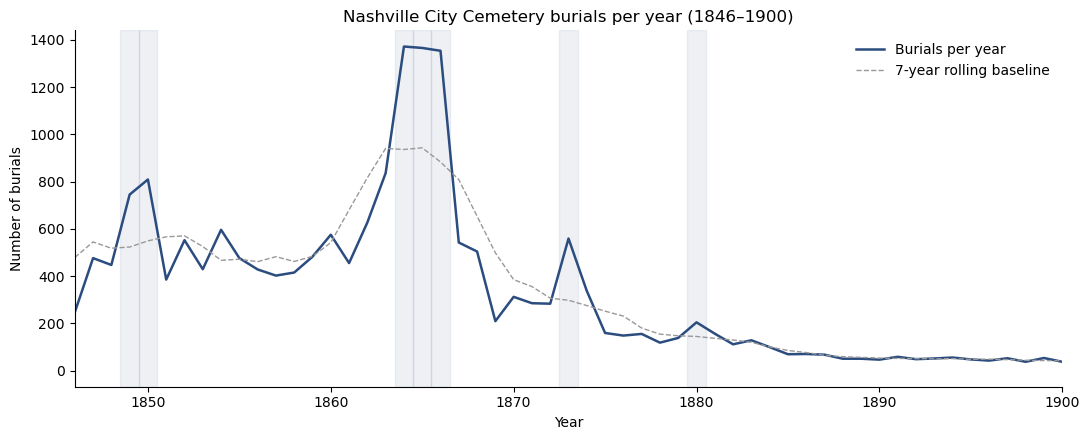

In [9]:
import matplotlib.pyplot as plt

yearly = df["Burial Year"].value_counts().sort_index()
full_years = yearly.reindex(range(1846, 1980), fill_value=0)
rolling_baseline = full_years.rolling(window=7, center=True, min_periods=1).mean()
spike_ratio = (full_years / rolling_baseline.replace(0, pd.NA)).fillna(0)

spike_years = full_years[(spike_ratio > 1.4) & (full_years >= 100)]
print("Years flagged as spikes (>40% above a 7-year rolling baseline, min. 100 burials):")
print(spike_years)

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(full_years.index, full_years.values, color="#2b4c7e", linewidth=1.8, label="Burials per year")
ax.plot(rolling_baseline.index, rolling_baseline.values, color="#999999", linewidth=1,
        linestyle="--", label="7-year rolling baseline")
for yr in spike_years.index:
    ax.axvspan(yr - 0.5, yr + 0.5, color="#2b4c7e", alpha=0.08)
ax.set_title("Nashville City Cemetery burials per year (1846–1900)")
ax.set_xlabel("Year")
ax.set_ylabel("Number of burials")
ax.set_xlim(1846, 1900)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

Two clusters and two single years get flagged. Most have a plausible historical match

- **1849–1850** (745, 809 burials): lines up with the severe cholera epidemic that hit Nashville and much of the U.S. in 1849–50.
- **1864–1866** (1,372 / 1,366 / 1,354 — the three biggest years in the entire dataset): Nashville was under Union military occupation from 1862 onward and served as a major hospital and supply hub for the rest of the Civil War; the Battle of Nashville was fought in December 1864. Combat deaths, wartime disease in crowded military camps and hospitals, and the general disruption of a garrisoned city are a reasonable explanation for a spike this size, this sustained.
- **1873** (559 burials): matches the major cholera epidemic that swept the Mississippi Valley and mid-South that year.
- **1880** (204 burials): flagged by the same rule, but the explanation is weaker. By this point Nashville City Cemetery had largely closed to new burials (other cemeteries had taken over as the city's primary burial grounds), so year-to-year counts here are small and volatile — a jump from ~150 to ~204 in a low-volume period can be statistical noise rather than a real mortality event. I don't have a specific historical cause to point to for this one, and the small sample size means the "spike" is less trustworthy than the other three.

So: three of the four flagged spikes have solid historical backing and numbers large enough to be meaningful